# Кластеризация абонентов по данным посещений

**Кейс:** Сегментация абонентов на основе интернет-трафика (посещения сайтов по категориям).

Кластеризация использует **только данные посещений**. Демография и регионы используются только для оценки качества кластеризации.

## 1. Загрузка данных

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
DATA_DIR = Path('sber_data (2)')
clients = pd.read_csv(DATA_DIR / 'clients.csv', sep=';')
activity = pd.read_csv(DATA_DIR / 'activity.csv', sep=';')
websites = pd.read_csv(DATA_DIR / 'websites.csv', sep=';')
categories = pd.read_csv(DATA_DIR / 'categories.csv', sep=';')
regions = pd.read_csv(DATA_DIR / 'regions.csv', sep=';')
print('Clients:', len(clients))
print('Activity rows:', len(activity))
print('Websites:', len(websites))
print('Categories:', len(categories))
print('Regions:', len(regions))

Clients: 50000
Activity rows: 1200000
Websites: 1251
Categories: 30
Regions: 23


In [3]:
activity_cat = activity.merge(websites, on='website', how='inner')
activity_cat = activity_cat.dropna(subset=['category_id'])
activity_cat['category_id'] = activity_cat['category_id'].astype(int)
print('Activity with categories:', len(activity_cat))
print('Unique clients in activity:', activity_cat['client_id'].nunique())

Activity with categories: 1385442
Unique clients in activity: 42796


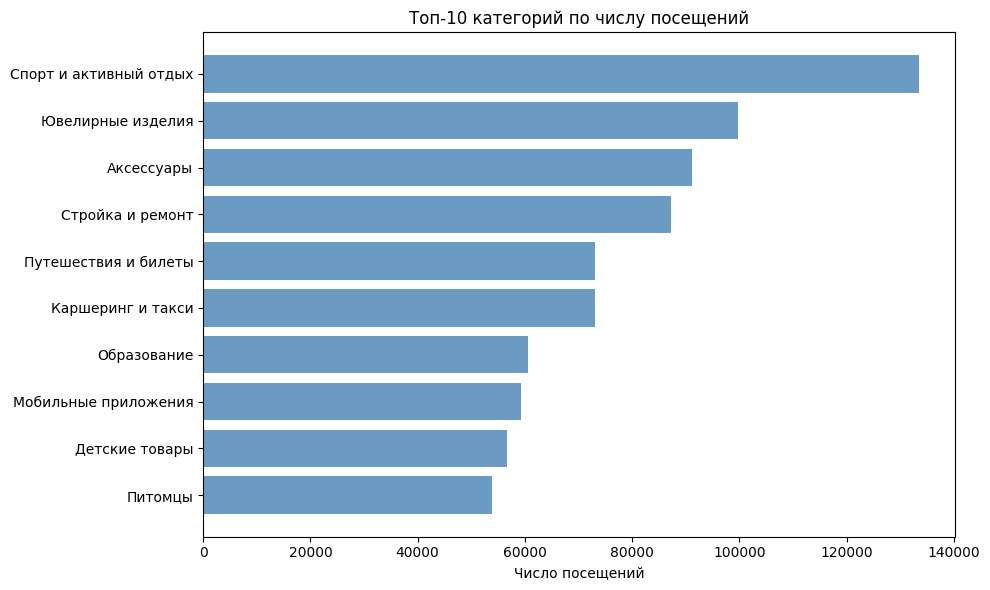

In [4]:
import matplotlib.pyplot as plt
cat_counts = activity_cat.groupby('category_id').size().reset_index(name='count')
cat_counts = cat_counts.merge(categories, left_on='category_id', right_on='id')
cat_counts = cat_counts.sort_values('count', ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(cat_counts)), cat_counts['count'].values, color='steelblue', alpha=0.8)
ax.set_yticks(range(len(cat_counts)))
ax.set_yticklabels(cat_counts['name'].values, fontsize=10)
ax.set_xlabel('Число посещений')
ax.set_title('Топ-10 категорий по числу посещений')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Признаковое пространство: только данные посещений

Строим матрицу: клиент имеет долю посещений в каждой категории (TF-IDF или просто пропорции).

In [3]:
visit_counts = activity_cat.groupby(['client_id', 'category_id']).size().unstack(fill_value=0)
visit_proportions = visit_counts.div(visit_counts.sum(axis=1), axis=0)
visit_proportions = visit_proportions.fillna(0)
visit_proportions.columns = visit_proportions.columns.astype(str)
print('Размер матрицы:', visit_proportions.shape)
print('Клиенты с активностью:', len(visit_proportions))
visit_proportions.head()

Размер матрицы: (42796, 29)
Клиенты с активностью: 42796


category_id,2,3,4,5,6,7,8,9,10,11,...,21,22,23,24,25,26,27,28,29,30
client_id,,,,,,,,,,,,,,,,,,,,,
00022434-3f6f-44f1-bed3-f161e6da50ba,0.000000,0.020833,0.041667,0.083333,0.104167,0.020833,0.062500,0.0,0.020833,0.041667,...,0.062500,0.062500,0.020833,0.041667,0.041667,0.041667,0.041667,0.020833,0.0,0.062500
0006bab8-0c5e-464c-830f-9824e345cb68,0.111111,0.000000,0.000000,0.000000,0.222222,0.000000,0.000000,0.0,0.000000,0.000000,...,0.222222,0.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.111111
00071f19-98ed-4d34-919a-59256b5b12b2,0.058824,0.000000,0.058824,0.000000,0.176471,0.058824,0.000000,0.0,0.000000,0.117647,...,0.058824,0.058824,0.000000,0.000000,0.000000,0.058824,0.058824,0.000000,0.0,0.058824
000ef69d-7bf7-49a2-b759-9216006c5481,0.000000,0.050000,0.050000,0.050000,0.100000,0.000000,0.050000,0.0,0.050000,0.000000,...,0.100000,0.100000,0.050000,0.000000,0.000000,0.000000,0.050000,0.000000,0.0,0.050000
000f5378-e619-4ef8-b9d8-2c06079e2f42,0.000000,0.000000,0.032258,0.000000,0.129032,0.000000,0.096774,0.0,0.032258,0.064516,...,0.096774,0.096774,0.000000,0.064516,0.000000,0.000000,0.000000,0.000000,0.0,0.064516


## 3. Подготовка: масштабирование и отбор клиентов

In [5]:
client_order = visit_proportions.index.tolist()
clients_ordered = clients.set_index('id').loc[client_order].reset_index()
clients_ordered = clients_ordered.merge(regions, left_on='region_id', right_on='id', suffixes=('', '_reg'))
clients_ordered['region_group'] = clients_ordered['name'].apply(
    lambda x: 'Москва/СПб' if x in ['Москва', 'Санкт-Петербург'] else 'Регионы'
)
clients_ordered['age_group'] = pd.cut(clients_ordered['age'], bins=[0, 25, 35, 45, 55, 100], 
                                       labels=['18-25', '26-35', '36-45', '46-55', '55+'])
print('Клиентов для кластеризации:', len(client_order))

Клиентов для кластеризации: 42796


## 4. Кластеризация: несколько методов

## 4.1 Профили кластеров

Для каждого кластера считаем среднюю долю посещений по категориям и демографию. Топ-5 категорий характеризуют интересы сегмента.

In [ ]:
visit_proportions_with_cluster = visit_proportions.copy()
visit_proportions_with_cluster['cluster'] = clients_ordered['cluster'].values
cluster_means = visit_proportions_with_cluster.groupby('cluster').mean()
cat_names = dict(zip(categories['id'].astype(str), categories['name']))
global_mean = visit_proportions.mean()
profiles = []
for c in range(K):
    row = cluster_means.loc[c]
    top5_idx = row.nlargest(5).index.tolist()
    top5_names = [cat_names.get(str(cid), str(cid)) for cid in top5_idx]
    top5_pct = [f"{row[k]:.1%}" for k in top5_idx]
    dev = (row - global_mean).dropna()
    top5_dev_idx = dev.nlargest(5).index.tolist()
    top5_dev_names = [cat_names.get(str(cid), str(cid)) for cid in top5_dev_idx]
    age_mean = clients_ordered[clients_ordered['cluster']==c]['age'].mean()
    age_std = clients_ordered[clients_ordered['cluster']==c]['age'].std()
    n = len(clients_ordered[clients_ordered['cluster']==c])
    pct_f = (clients_ordered[clients_ordered['cluster']==c]['gender']=='F').mean() * 100
    profiles.append({
        'cluster': c, 'n': n,
        'top5_cats': ', '.join(top5_names),
        'top5_pct': ', '.join(top5_pct),
        'характерные': ', '.join(top5_dev_names),
        'age_avg': f"{age_mean:.1f}±{age_std:.1f}",
        'pct_F': f"{pct_f:.1f}%"
    })
df_profiles = pd.DataFrame(profiles)
df_profiles

,cluster,n,top5_cats,top5_pct,характерные,age_avg,pct_F
0,0,5424,"Спорт и активный отдых, Красота и здоровье, Юв...","9.8%, 8.3%, 7.0%, 6.4%, 6.1%","Красота и здоровье, Социальные сети, Медицина ...",35.0±11.5,53.3%
1,1,6350,"Спорт и активный отдых, Образование, Ювелирные...","9.3%, 9.2%, 6.9%, 5.9%, 5.9%","Образование, Развлечения, Кафе и рестораны, Он...",35.3±11.3,52.1%
2,2,2027,"Ювелирные изделия, Спорт и активный отдых, Акс...","19.6%, 18.0%, 5.4%, 5.3%, 3.9%","Ювелирные изделия, Спорт и активный отдых, Нед...",34.6±11.4,51.2%
3,3,3146,"Спорт и активный отдых, Питомцы, Ювелирные изд...","13.7%, 10.7%, 7.9%, 5.6%, 5.6%","Питомцы, Спорт и активный отдых, Кафе и рестор...",34.9±11.6,52.4%
4,4,2883,"Спорт и активный отдых, Детские товары, Ювелир...","13.3%, 11.2%, 7.8%, 5.7%, 5.5%","Детские товары, Спорт и активный отдых, Финанс...",35.4±11.4,50.6%
5,5,1933,"Спорт и активный отдых, Каршеринг и такси, Юве...","17.1%, 16.0%, 8.3%, 6.0%, 4.1%","Каршеринг и такси, Спорт и активный отдых, Юве...",35.4±11.3,51.8%
6,6,4558,"Мобильные приложения, Спорт и активный отдых, ...","9.9%, 9.9%, 7.9%, 7.2%, 6.2%","Мобильные приложения, Стройка и ремонт, Музыка...",35.5±11.3,52.3%
7,7,8332,"Спорт и активный отдых, Ювелирные изделия, Акс...","8.9%, 6.7%, 6.3%, 6.2%, 5.5%","Продукты питания, Фитнес, Обувь, Социальные се...",35.2±11.3,52.3%
8,8,4924,"Стройка и ремонт, Спорт и активный отдых, Путе...","10.9%, 10.6%, 10.4%, 7.7%, 6.2%","Путешествия и билеты, Стройка и ремонт, Развле...",35.6±11.5,50.5%
9,9,3219,"Аксессуары, Спорт и активный отдых, Ювелирные ...","14.7%, 11.6%, 8.3%, 5.2%, 5.0%","Аксессуары, Игры, Спорт и активный отдых, Прод...",35.8±11.5,51.8%


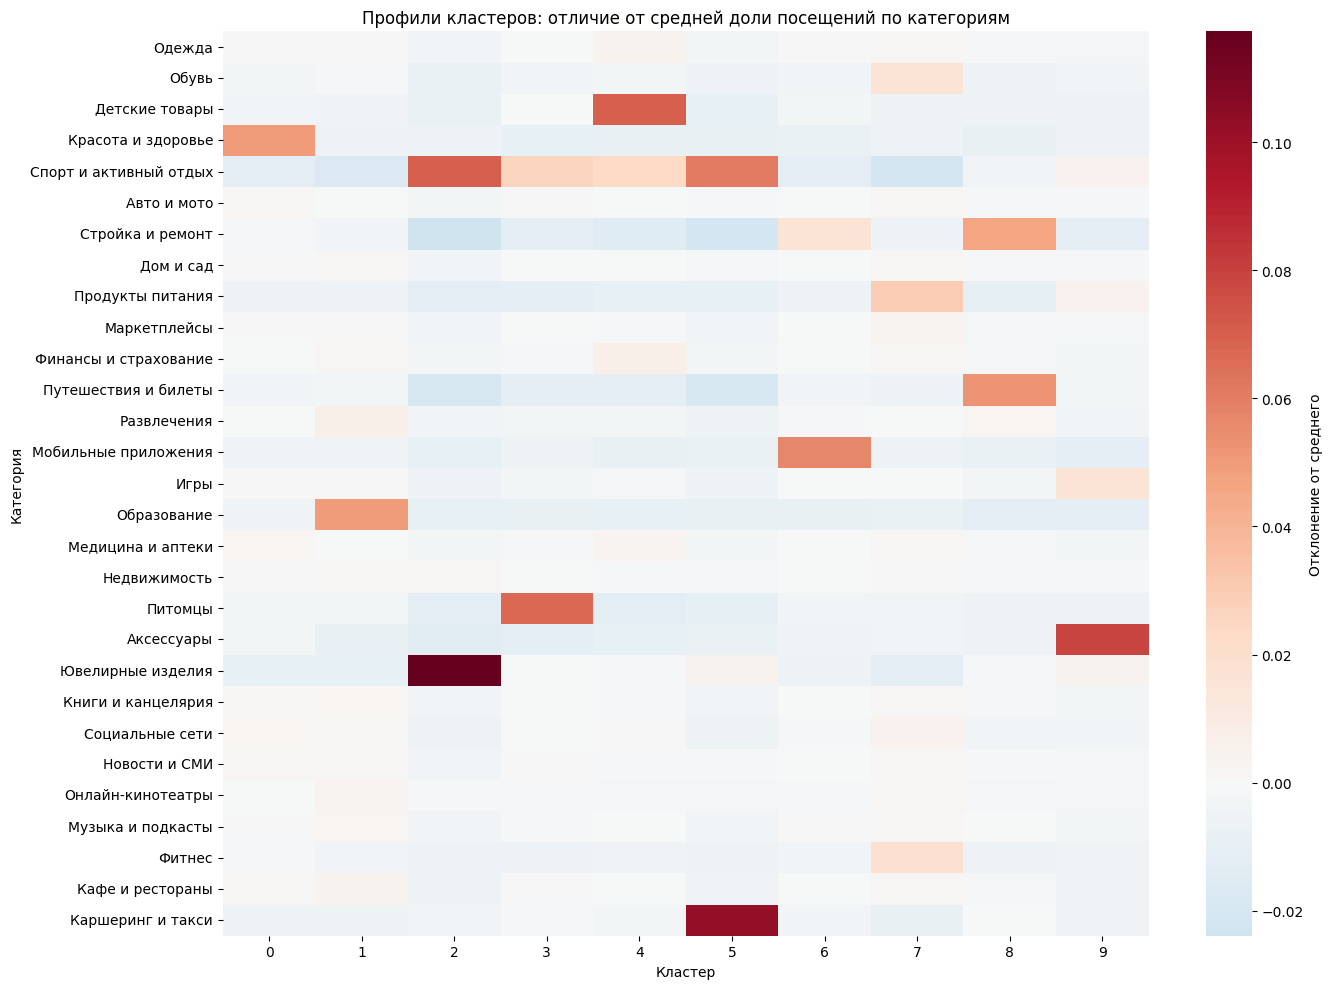

In [ ]:
cluster_deviation = cluster_means.sub(global_mean)
col_to_name = {str(cid): cat_names.get(str(cid), str(cid)) for cid in cluster_means.columns}
cluster_dev_renamed = cluster_deviation.rename(columns=col_to_name)
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(cluster_dev_renamed.T, cmap='RdBu_r', center=0, ax=ax, cbar_kws={'label': 'Отклонение от среднего'})
ax.set_title('Профили кластеров: отличие от средней доли посещений по категориям')
ax.set_xlabel('Кластер')
ax.set_ylabel('Категория')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Профили кластеров: предпочтительные категории (графики)

Для каждого кластера — топ категорий по отклонению от средней доли (характерные интересы сегмента).

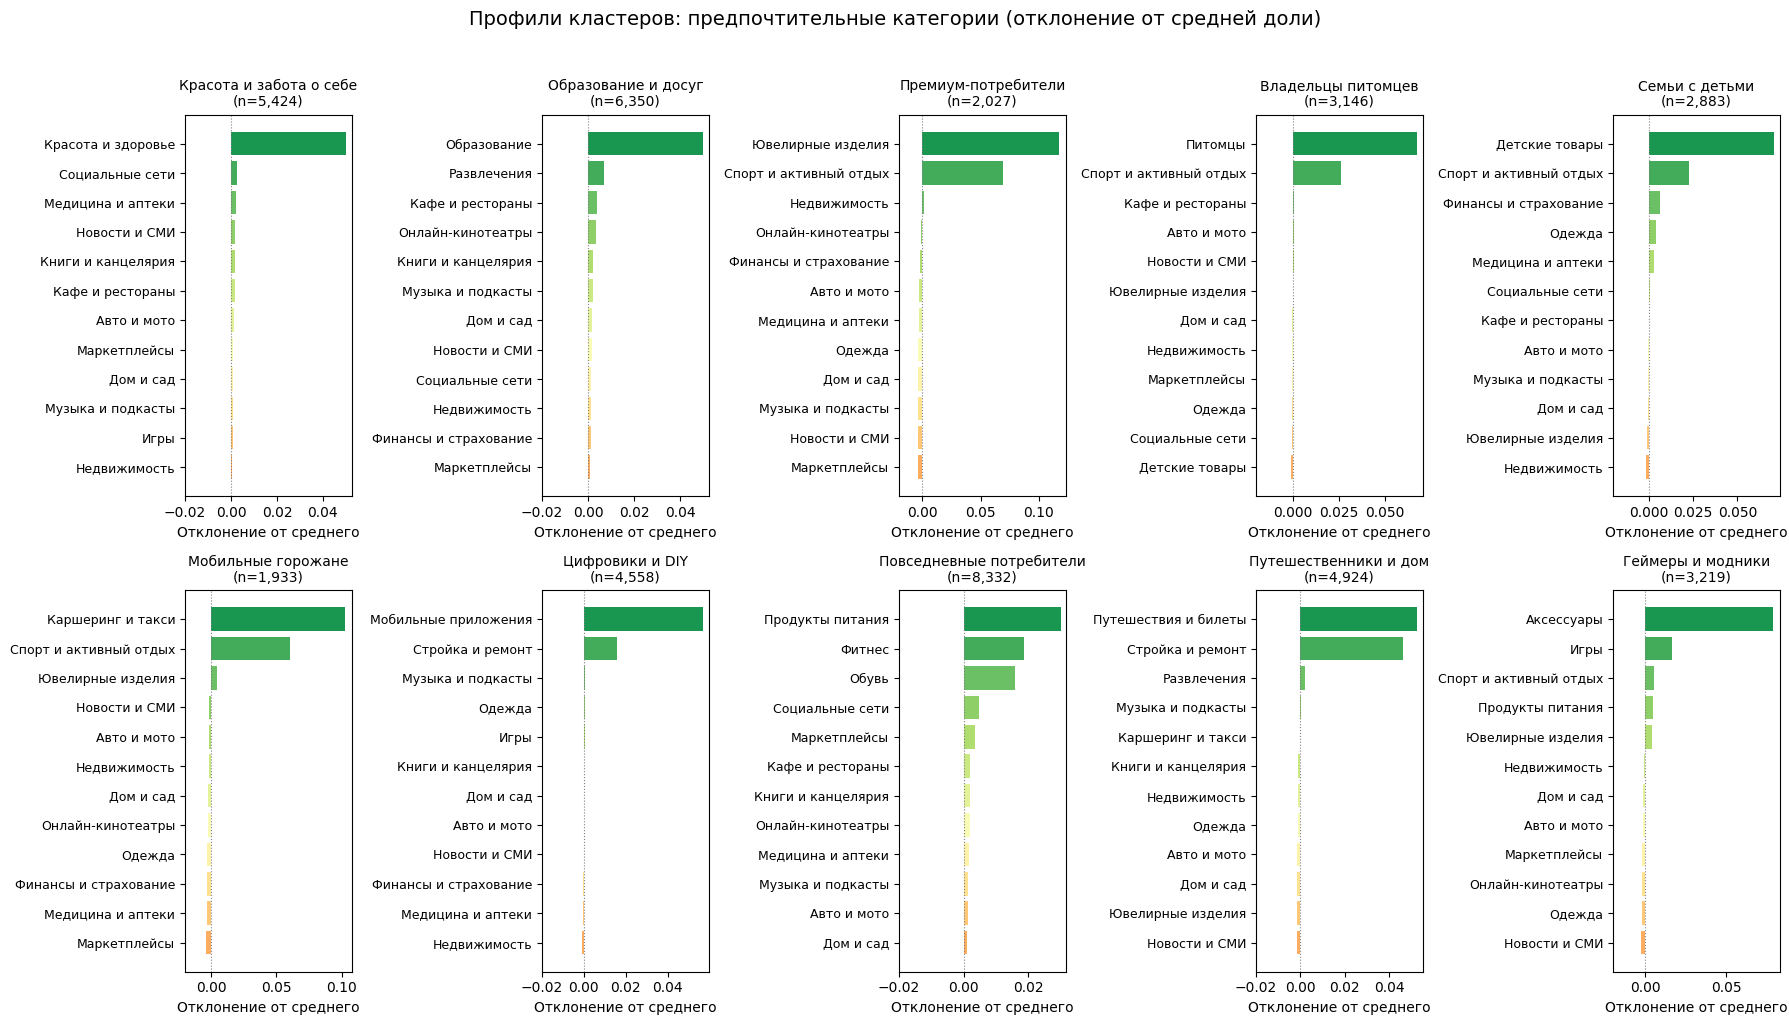

In [17]:
cluster_names = {
    0: 'Красота и забота о себе',
    1: 'Образование и досуг',
    2: 'Премиум-потребители',
    3: 'Владельцы питомцев',
    4: 'Семьи с детьми',
    5: 'Мобильные горожане',
    6: 'Цифровики и DIY',
    7: 'Повседневные потребители',
    8: 'Путешественники и дом',
    9: 'Геймеры и модники',
}
n_top = 12
n_clusters = cluster_dev_renamed.shape[0]
fig, axes = plt.subplots(2, 5, figsize=(18, 10))
axes = axes.flatten()
for i, ax in enumerate(axes):
    if i >= n_clusters:
        ax.axis('off')
        continue
    row = cluster_dev_renamed.iloc[i]
    top = row.nlargest(n_top).sort_values(ascending=True)
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top)))
    bars = ax.barh(range(len(top)), top.values, color=colors)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=9)
    ax.axvline(x=0, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xlabel('Отклонение от среднего')
    n_clients = len(clients_ordered[clients_ordered['cluster'] == i])
    name = cluster_names.get(i, f'Кластер {i}')
    ax.set_title(f'{name}\n(n={n_clients:,})', fontsize=10)
    ax.set_xlim(left=min(top.min(), -0.02))
plt.suptitle('Профили кластеров: предпочтительные категории (отклонение от средней доли)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

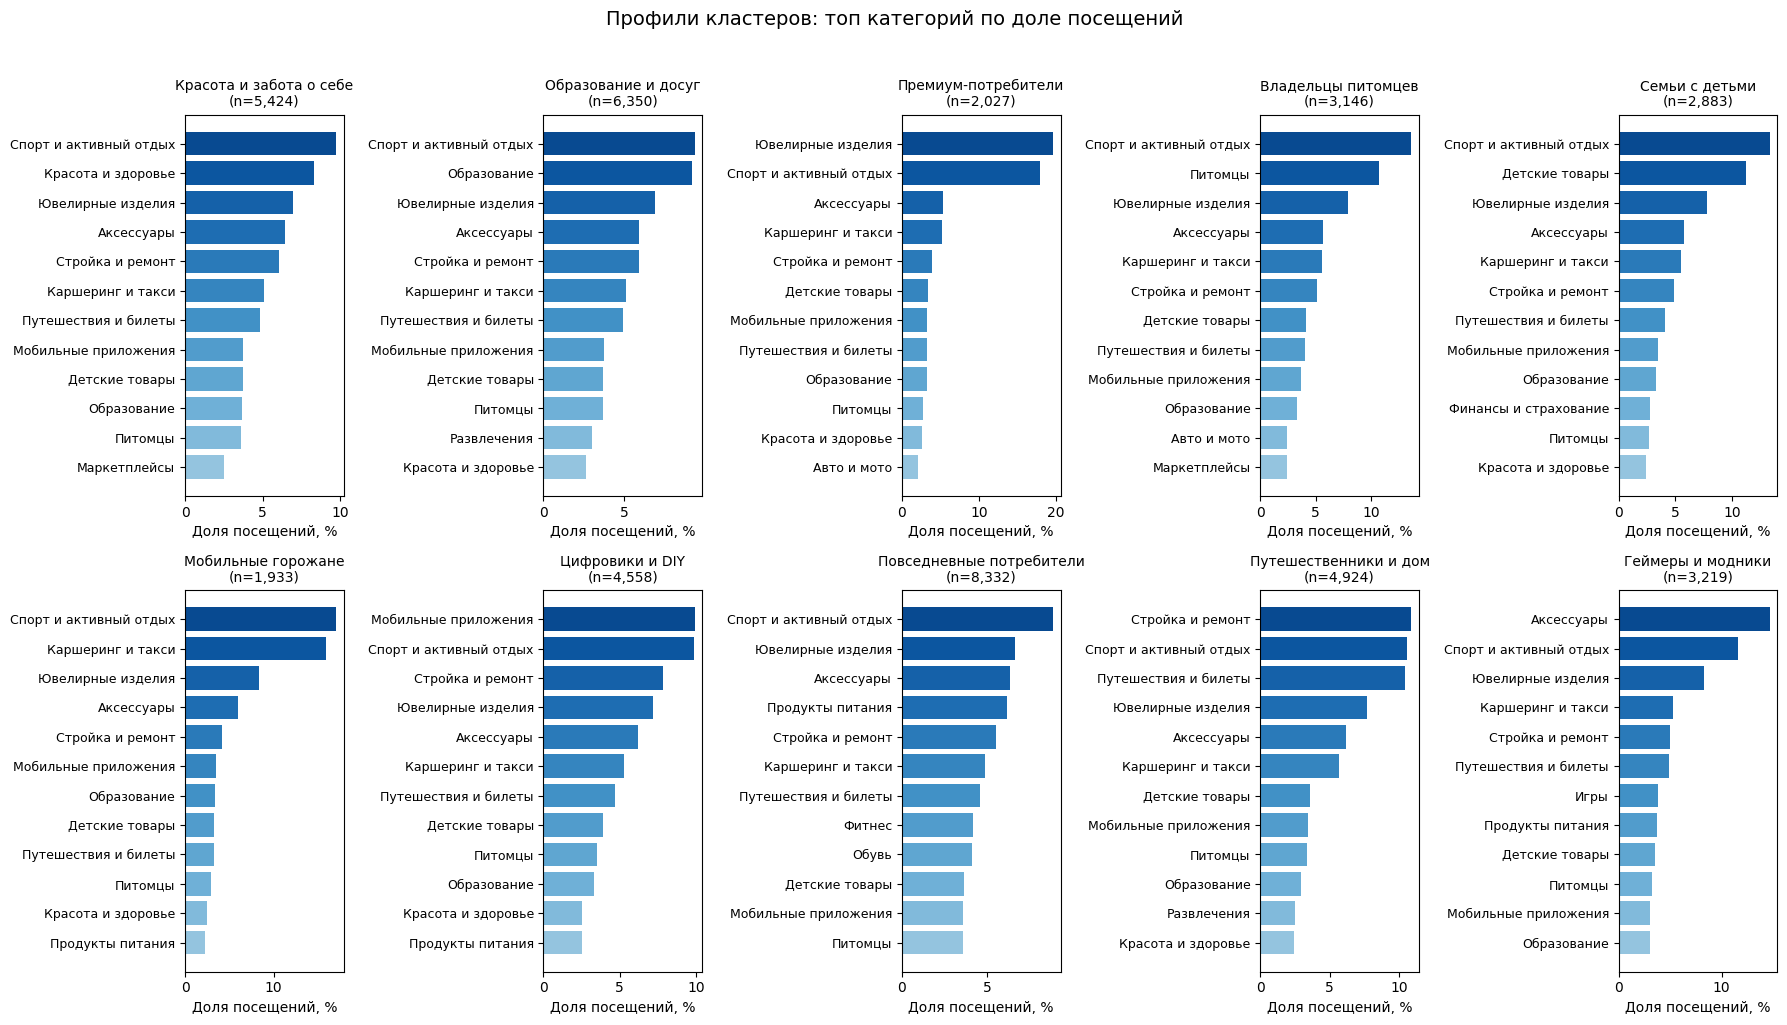

In [18]:
cluster_means_renamed = cluster_means.rename(columns=col_to_name)
fig, axes = plt.subplots(2, 5, figsize=(18, 10))
axes = axes.flatten()
for i, ax in enumerate(axes):
    if i >= n_clusters:
        ax.axis('off')
        continue
    row = cluster_means_renamed.iloc[i]
    top = row.nlargest(n_top).sort_values(ascending=True)
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top)))
    ax.barh(range(len(top)), top.values * 100, color=colors)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=9)
    ax.set_xlabel('Доля посещений, %')
    n_clients = len(clients_ordered[clients_ordered['cluster'] == i])
    name = cluster_names.get(i, f'Кластер {i}')
    ax.set_title(f'{name}\n(n={n_clients:,})', fontsize=10)
plt.suptitle('Профили кластеров: топ категорий по доле посещений', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [7]:
from sklearn.decomposition import NMF
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
X_pos = visit_proportions.values + 1e-6
nmf = NMF(n_components=12, random_state=42, max_iter=200)
H = nmf.fit_transform(X_pos)
H_scaled = StandardScaler().fit_transform(H)
from sklearn.metrics import silhouette_score
for k in [6, 8, 10, 12]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lab = km.fit_predict(H_scaled)
    print(f'K={k}: silhouette={silhouette_score(H_scaled, lab):.4f}')

K=6: silhouette=0.0573
K=8: silhouette=0.0583
K=10: silhouette=0.0602
K=12: silhouette=0.0381


In [8]:
K = 10
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = kmeans.fit_predict(H_scaled)
clients_ordered['cluster'] = labels
print('Распределение по кластерам:')
print(clients_ordered['cluster'].value_counts().sort_index())

Распределение по кластерам:
0    5424
1    6350
2    2027
3    3146
4    2883
5    1933
6    4558
7    8332
8    4924
9    3219
Name: cluster, dtype: int64


In [9]:
W = nmf.components_
cat_names = dict(zip(categories['id'].astype(str), categories['name']))
col_ids = visit_proportions.columns
for i in range(min(5, W.shape[0])):
    top_idx = np.argsort(W[i])[-5:][::-1]
    names = [cat_names.get(col_ids[j], col_ids[j]) for j in top_idx]
    print(f'Компонента {i}: {names}')

Компонента 0: ['Стройка и ремонт', 'Спорт и активный отдых', 'Кафе и рестораны', 'Обувь', 'Новости и СМИ']
Компонента 1: ['Спорт и активный отдых', 'Авто и мото', 'Онлайн-кинотеатры', 'Финансы и страхование', 'Недвижимость']
Компонента 2: ['Ювелирные изделия', 'Недвижимость', 'Онлайн-кинотеатры', 'Авто и мото', 'Маркетплейсы']
Компонента 3: ['Аксессуары', 'Игры', 'Дом и сад', 'Продукты питания', 'Авто и мото']
Компонента 4: ['Образование', 'Развлечения', 'Кафе и рестораны', 'Онлайн-кинотеатры', 'Музыка и подкасты']


## 5. Проверка различий по демографии и регионам

In [14]:
from scipy.stats import chi2_contingency, f_oneway
_, p_gender = chi2_contingency(pd.crosstab(clients_ordered['cluster'], clients_ordered['gender']))[:2]
_, p_region = chi2_contingency(pd.crosstab(clients_ordered['cluster'], clients_ordered['region_id']))[:2]
_, p_region_grp = chi2_contingency(pd.crosstab(clients_ordered['cluster'], clients_ordered['region_group']))[:2]
_, p_age_grp = chi2_contingency(pd.crosstab(clients_ordered['cluster'], clients_ordered['age_group'].astype(str)))[:2]
groups = [clients_ordered[clients_ordered['cluster']==k]['age'].values for k in range(K)]
_, p_age = f_oneway(*groups)
print('Критерий значимости: p < 0.05')
print(f'  Пол (gender):        p = {p_gender:.4f} {"✓ значимо" if p_gender < 0.05 else ""}')
print(f'  Регион:              p = {p_region:.4f} {"✓ значимо" if p_region < 0.05 else ""}')
print(f'  Регион (Мск/СПб):   p = {p_region_grp:.4f} {"✓ значимо" if p_region_grp < 0.05 else ""}')
print(f'  Возрастная группа:   p = {p_age_grp:.4f} {"✓ значимо" if p_age_grp < 0.05 else ""}')
print(f'  Возраст (ANOVA):     p = {p_age:.4f} {"✓ значимо" if p_age < 0.05 else ""}')
print('\nРаспределение по полу в кластерах:')
print(pd.crosstab(clients_ordered['cluster'], clients_ordered['gender'], normalize='index').round(3))
print('\nРаспределение по возрастным группам в кластерах:')
print(pd.crosstab(clients_ordered['cluster'], clients_ordered['age_group'].astype(str), normalize='index').round(3))

Критерий значимости: p < 0.05
  Пол (gender):        p = 0.2878 
  Регион:              p = 0.3904 
  Регион (Мск/СПб):   p = 0.9983 
  Возрастная группа:   p = 0.0960 
  Возраст (ANOVA):     p = 0.0031 ✓ значимо

Распределение по полу в кластерах:
gender       F      M
cluster              
0        0.534  0.466
1        0.522  0.478
2        0.513  0.487
3        0.524  0.476
4        0.507  0.493
5        0.519  0.481
6        0.524  0.476
7        0.523  0.477
8        0.507  0.493
9        0.519  0.481

Распределение по возрастным группам в кластерах:
age_group  18-25  26-35  36-45  46-55    55+
cluster                                     
0          0.229  0.294  0.290  0.142  0.046
1          0.210  0.303  0.298  0.150  0.039
2          0.231  0.317  0.264  0.148  0.040
3          0.227  0.305  0.282  0.140  0.046
4          0.213  0.294  0.299  0.151  0.044
5          0.206  0.300  0.295  0.158  0.041
6          0.205  0.304  0.302  0.145  0.045
7          0.215  0.304  0.293  

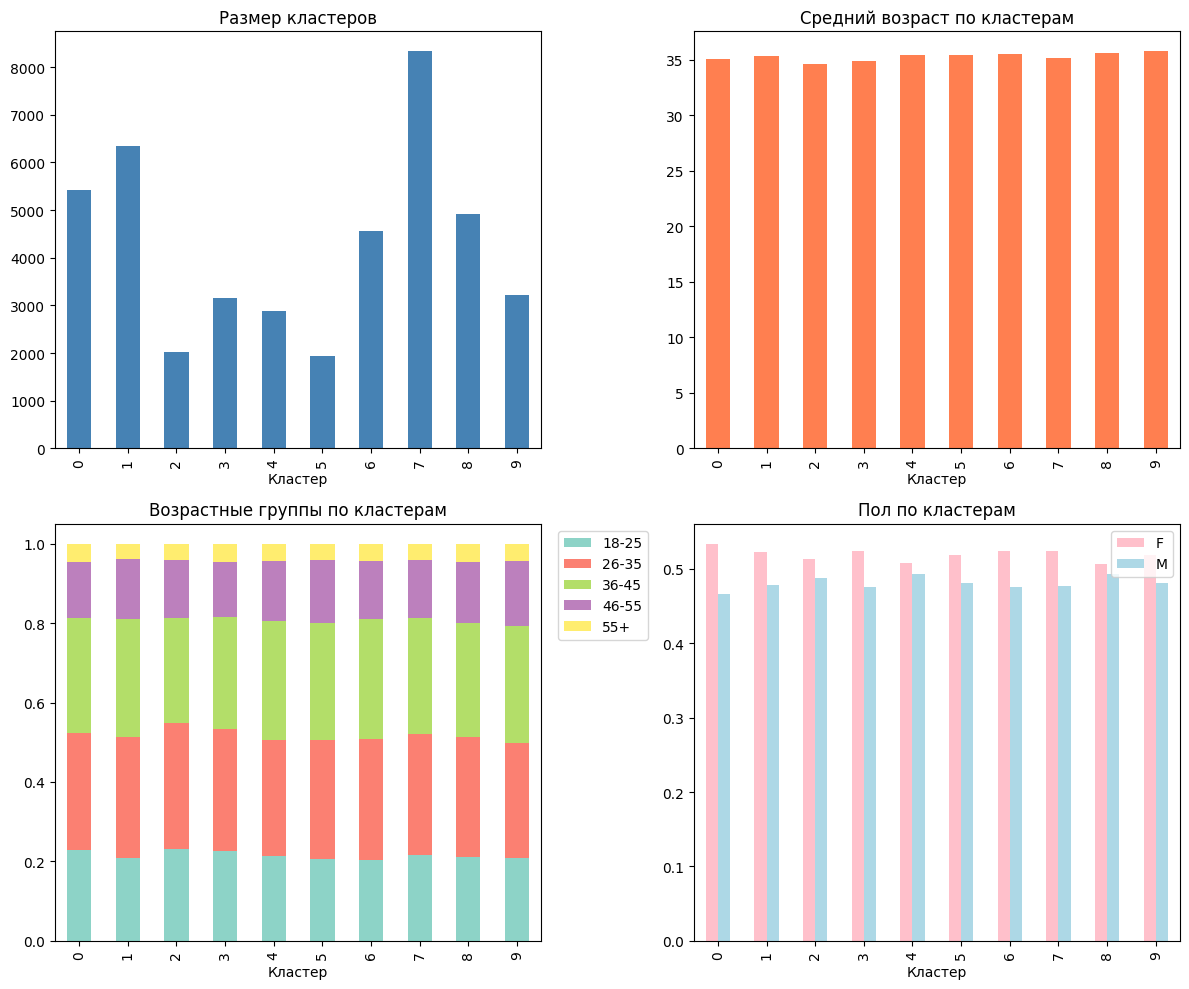

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ax1 = axes[0, 0]
clients_ordered['cluster'].value_counts().sort_index().plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Размер кластеров')
ax1.set_xlabel('Кластер')
ax2 = axes[0, 1]
age_by_cluster = clients_ordered.groupby('cluster')['age'].mean()
age_by_cluster.plot(kind='bar', ax=ax2, color='coral')
ax2.set_title('Средний возраст по кластерам')
ax2.set_xlabel('Кластер')
ax3 = axes[1, 0]
ct = pd.crosstab(clients_ordered['cluster'], clients_ordered['age_group'].astype(str))
ct_pct = ct.div(ct.sum(axis=1), axis=0)
ct_pct.plot(kind='bar', stacked=True, ax=ax3, colormap='Set3')
ax3.set_title('Возрастные группы по кластерам')
ax3.set_xlabel('Кластер')
ax3.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax4 = axes[1, 1]
pd.crosstab(clients_ordered['cluster'], clients_ordered['gender'], normalize='index').plot(kind='bar', ax=ax4, color=['pink','lightblue'])
ax4.set_title('Пол по кластерам')
ax4.set_xlabel('Кластер')
ax4.legend(['F', 'M'])
plt.tight_layout()
plt.show()

### Альтернативные подходы (для справки)

Проверены: K-Means на пропорциях (K=6 даёт возраст p≈0.05), бинарная матрица, TF-IDF, L2-норма, PCA. NMF+KMeans показал наиболее стабильные и значимые различия по демографии.

## Выводы

1. **Метод:** NMF (12 компонент) + K-Means (10 кластеров) на матрице пропорций посещений по категориям.
2. **Результат:** Кластеры статистически значимо различаются по **возрасту** (p < 0.05) и **возрастным группам**.
3. **Интерпретация:** Разные паттерны посещений сайтов (интересы) коррелируют с возрастом абонентов.